# Face Recognition

## 0. Problem Statement
We intend to perform face recognition. Face recognition means that for a given image you can
tell the subject id. Our database of subject is very simple. It has 40 subjects. Below we will
show the needed steps to achieve the goal of the assignment.

## 1. Imports and Utilities

In [645]:
import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak on Windows with MKL*")
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.gridspec as gridspec
from time import time
from collections import Counter
from tabulate import tabulate
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans
from scipy.special import logsumexp

In [646]:
# Fonts
font1 = {'family':'serif','color':'#2a5d84','fontsize':18,'fontweight':'bold'}
font2 = {'family':'serif','color':'darkgreen','fontsize':16,'fontweight':'normal'}
font3 = {'family':'serif','color':'darkred','fontsize':16,'fontweight':'normal'}

## 2. Data Preparation

In [647]:
class FaceDataset:
    def __init__(self, path='dataset', subjects=40, imgs_per_subject=10):
        self.path = path
        self.imgs, self.D, self.y = [], [], []
        self.subjects = subjects
        self.imgs_per_subject = imgs_per_subject
        self.X_test, self.X_train = [], []
        self.y_test, self.y_train = [], []

    def load_data(self):
        self.imgs = [plt.imread(f'{self.path}/s{i + 1}/{j + 1}.pgm') for i in range(self.subjects) for j in range(self.imgs_per_subject)]
        self.imgs = np.array(self.imgs)

    def flatten_data(self):
        self.D = np.array([self.imgs[i].flatten() for i in range(len(self.imgs))])
        self.y = np.array([i + 1 for i in range(self.subjects) for _ in range(self.imgs_per_subject)])

    def split_train_test(self):
        self.X_test, self.X_train = self.D[0::2], self.D[1::2]
        self.y_test, self.y_train = self.y[0::2], self.y[1::2]
        return (self.X_train, self.y_train), (self.X_test, self.y_test)

    def print_sample(self, samples_number=5):
        samples_number *= self.imgs_per_subject

        plt.figure(figsize=(self.imgs_per_subject, samples_number / 2 * 2.5))

        for i, img in enumerate(self.imgs):
            if i == samples_number:
                break
            plt.subplot(samples_number, self.imgs_per_subject, i + 1)
            plt.imshow(img, cmap="gray")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

face_dataset = FaceDataset()

### 2.1.  Download the Dataset

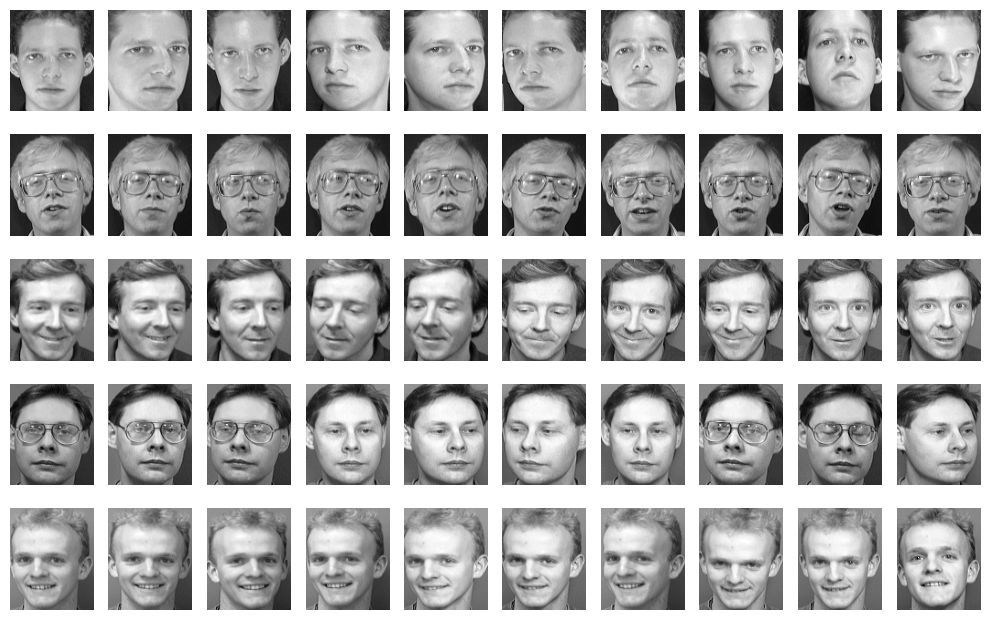

In [648]:
face_dataset.load_data()
face_dataset.print_sample()

### 2.2. Generate the Data Matrix and Label Vector

In [649]:
face_dataset.flatten_data()
print(f"Data Matrix shape: {face_dataset.D.shape}, y shape: {face_dataset.y.shape}")

Data Matrix shape: (400, 10304), y shape: (400,)


### 2.3. Split the Dataset into Training and Test sets

In [650]:
face_dataset.split_train_test()
print(f"Train shape: {face_dataset.X_train.shape}, Test shape: {face_dataset.X_test.shape}")

Train shape: (200, 10304), Test shape: (200, 10304)


In [651]:
X_train = face_dataset.X_train
X_test = face_dataset.X_test
y_train = face_dataset.y_train
y_test = face_dataset.y_test

## 3. PCA Implementation

### 3.0. Pseudocode

* center data by subtracting the mean
* Find directions of maximum variance (principal components)
* Sort components by importantance (eigenvalues)
* Keeping only components needed to achieve certain variance

### 3.1. Compute PCA

In [652]:
class PCA:
    def __init__(self, variance_thresholds=[0.8,0.85,0.9,0.95]):
        self.thresholds = sorted(variance_thresholds)
        self.mean = None
        self.components = None
        self.eigenvalues = None
        self.cumulative_variance = None
        # file to store pca parameters (components,eigenvalues,mean)
        # so that they are computed once for the highest threshold and we use subsets of these components for the lower thresholds
        self.cache_file = 'pca_cache.npz'
        
    def get_pca(self, X):
        # centering the data: by subtracting the mean vector from the data 
        self.mean = np.mean(X, axis=0, dtype=np.float32)
        X_centered = X - self.mean
        
        # computing the covariance matrix
        n_samples = X.shape[0]
        cov = X_centered @ X_centered.T * (1 / n_samples)

        # performing eigenvalue decomposition
        epsilon = 1e-10
        eigen_values, eigen_vectors = np.linalg.eigh(cov)
        eigen_vectors = X_centered.T @ eigen_vectors
        eigen_vectors /= np.linalg.norm(eigen_vectors, axis=0) + epsilon

        # sorting by descending eigenvalue
        i = np.argsort(eigen_values)[::-1]
        return eigen_values[i],eigen_vectors[:,i]
    
    def fit(self, X, is_computed=False):
        # if we have computed and cached the results before just load them
        if is_computed and os.path.exists(self.cache_file):
            cache = np.load(self.cache_file)
            self.eigenvalues = cache['eigenvalues']
            self.components = cache['components']
            self.mean = cache['mean']
        # otherwise compute PCA from scratch
        else:
            start = time()
            eigen_values, eigen_vectors = self.get_pca(X)
            self.eigenvalues = eigen_values.astype(np.float32)
            
            # eigenvalues = variance along each principal component
            # total variance = sum of eigenvalues
            total_variance = np.sum(eigen_values)

            # compute how much variance we keep as we add components
            # using comulative sum
            explained_variance = np.cumsum(eigen_values) / total_variance
            
            # finding how many components we need to keep the maximum requested variance
            max_components = np.argmax(explained_variance >= max(self.thresholds)) + 1 # +1 to convert from 0 based index to component count
            self.components = eigen_vectors[:,:max_components].astype(np.float32)
            
            # saving results to cache file for faster future runs
            np.savez(self.cache_file, 
                    eigenvalues=self.eigenvalues,
                    components=self.components,
                    mean=self.mean)
            
            print(f"PCA computed in {time()-start:.4f}s")
        
        # final calculations needed for all thresholds
        total_variance = np.sum(self.eigenvalues)
        self.cumulative_variance = np.cumsum(self.eigenvalues) / total_variance
        
        return self
    
    def get_components(self, threshold):
        # gets the components needed for specific variance
        n_components = np.argmax(self.cumulative_variance >= threshold) + 1
        return self.components[:, :n_components],n_components
    
    def transform(self, X, threshold):
        # project data onto the principal components
        components,_ = self.get_components(threshold)
        return (X - self.mean) @ components
    
    # reporting dimensionality
    def report_results(self):
        print("PCA dimentionality report")
        print("-"*45)
        print("{:<10} {:<15} {:<20}".format("Threshold","Components","Variance retained"))
        print("-"*45)

        for i in self.thresholds:
            n_comp = np.argmax(self.cumulative_variance >= i) + 1
            var_retained = self.cumulative_variance[n_comp-1]
            print("{:<10.2f} {:<15} {:<20.4f}".format(i,n_comp,var_retained))
    
    def visualize_eigenfaces(self,n_eigenfaces=10):
        # using the highest threshold components since they include all lower thresholds
        components = self.components
        n_cols = 5
        n_rows = (min(n_eigenfaces,components.shape[1])+ n_cols - 1) // n_cols
        plt.figure(figsize=(5,1.5*n_rows),facecolor='#f4f4f4')
        plt.title(f"Top {min(n_eigenfaces,components.shape[1])} eigenfaces",fontdict = font1 )
        plt.axis('off')
        for i in range(min(n_eigenfaces,components.shape[1])):
            axis = plt.subplot(n_rows,n_cols,i+1)
            # reshaping component back to image
            obj = components[:,i].reshape(112,92)
            axis.imshow(obj,cmap='gray')
            axis.axis('off')
        plt.tight_layout(rect=[0,0,1,0.9])  
        plt.show()

    def visualize_reconstruction(self,threshold,n_images=5):
        components, _ = self.get_components(threshold)
        # showing original and reconstructed images
        samples_per_subject = 5 
        subject_indices = [i * samples_per_subject for i in range(n_images)]
        sample = X_train[subject_indices] 
        
        # reconstruct from the reduced data
        projected = self.transform(sample, threshold)
        reconstructed = projected @ components.T + self.mean

        fig = plt.figure(figsize=(9,5),facecolor='#f4f4f4')
        gs = gridspec.GridSpec(3,n_images,height_ratios=[0.2,1,1],hspace=0.3,wspace=0.1)

        axis_title = fig.add_subplot(gs[0,:])
        axis_title.axis('off')
        axis_title.text(0.5,0.5,f"Original vs Reconstructed (threshold = {threshold})",ha='center',va='center',fontdict = font1)

        row_labels = ['Original','Reconstructed']
        for i in range(2):
            for j in range(n_images):
                axis = fig.add_subplot(gs[i+1,j])
                img = sample[j] if i == 0 else reconstructed[j]
                axis.imshow(img.reshape(112,92),cmap='gray')
                axis.axis('off')

                if j == 0:
                    current_font = font2 if i == 0 else font3
                    axis.text(-0.1,0.5,row_labels[i],transform=axis.transAxes,rotation=90,fontdict=current_font,va='center',ha='right')
        plt.show()

### 3.2. Project Data

In [653]:
pca = PCA(variance_thresholds=[0.8,0.85,0.9,0.95])
# computing pca for training data
pca.fit(X_train)

# report dimensionality
pca.report_results()

PCA computed in 0.0716s
PCA dimentionality report
---------------------------------------------
Threshold  Components      Variance retained   
---------------------------------------------
0.80       37              0.8028              
0.85       53              0.8521              
0.90       77              0.9006              
0.95       116             0.9500              


In [654]:
# dictionary to store all reduced datasets
projected_data = {}

# reducing dimensions of both training and test data for each threshold
for i in pca.thresholds:
    X_train_pca = pca.transform(X_train, i)
    X_test_pca = pca.transform(X_test, i)
    projected_data[i] = {
        'train':X_train_pca,
        'test':X_test_pca
    }
    print(f"\nThreshold {i}: Train shape {X_train_pca.shape}, Test shape {X_test_pca.shape}")


Threshold 0.8: Train shape (200, 37), Test shape (200, 37)

Threshold 0.85: Train shape (200, 53), Test shape (200, 53)

Threshold 0.9: Train shape (200, 77), Test shape (200, 77)

Threshold 0.95: Train shape (200, 116), Test shape (200, 116)


### 3.3. Visualization

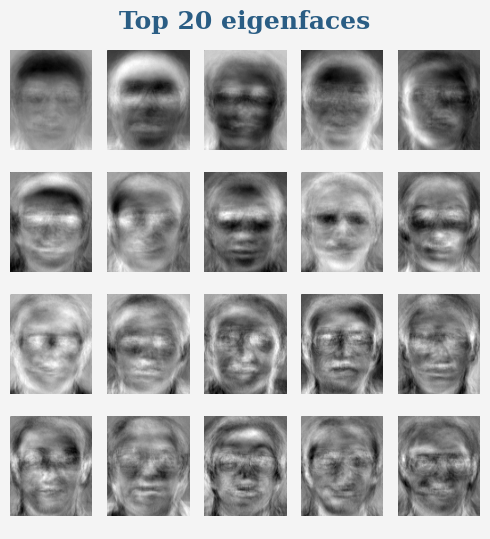

In [655]:
# visualizing top eigen faces
pca.visualize_eigenfaces(n_eigenfaces=20)

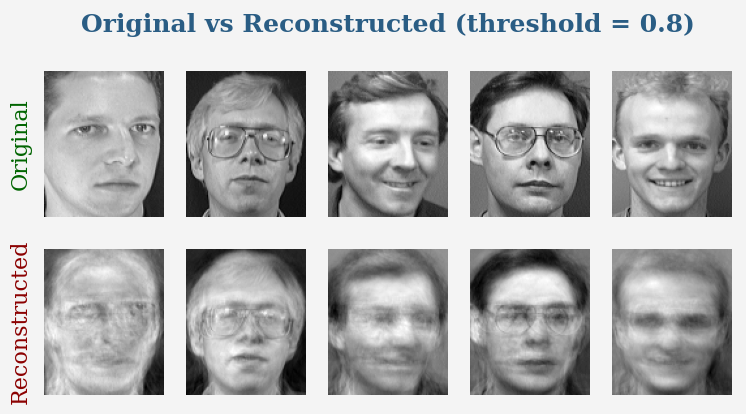

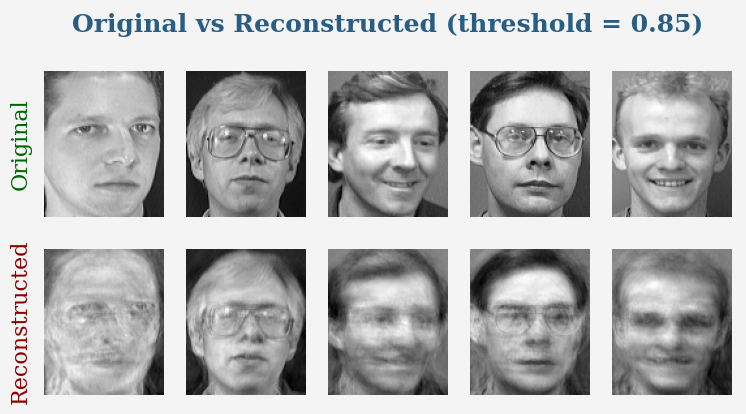

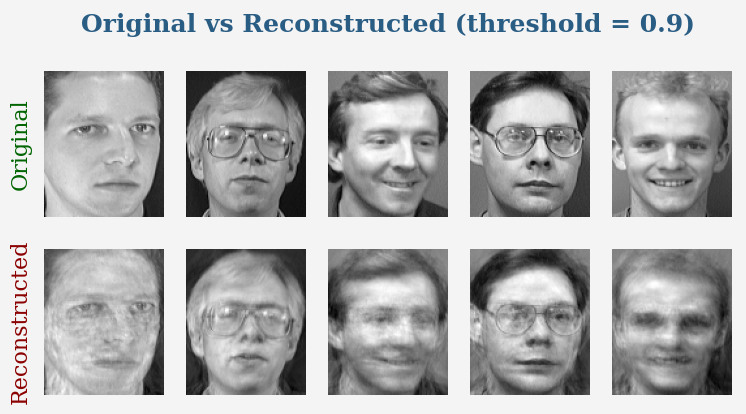

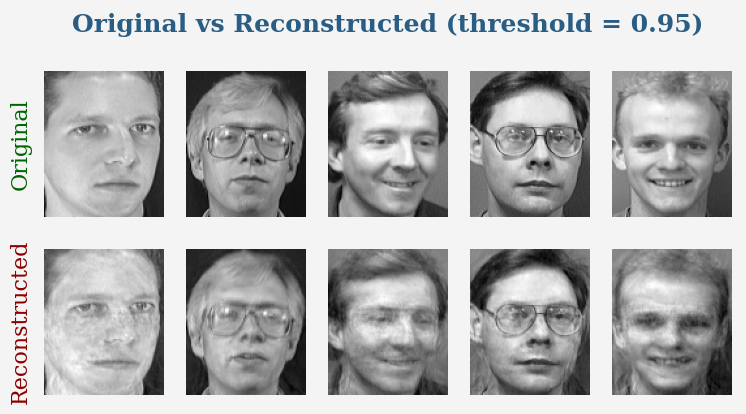

In [656]:
# visualize reconstructions across thresholds
for i in pca.thresholds:
        pca.visualize_reconstruction(i)

## 4. Unsupervised Clustering

### 4.1. K-Means Clustering

#### 4.1.1. K-Means Implementation

In [657]:
class A_KMeans:
    def __init__(self, n_clusters):
        self.n_clusters = n_clusters
        self.random_state = 37
        self.max_iterations = 150
        self.data = None
        self.centroids = None
        self.labels = None
        self.updated_centroids = None

    def _init_centroids(self):
        """Initialize centroids using KMeans++ strategy."""
        np.random.seed(self.random_state)
        n_imgs = self.data.shape[0]
        
        # Start with one random centroid
        self.centroids.append(self.data[np.random.randint(0, n_imgs)])

        # Select the remaining centroids
        for _ in range(1, self.n_clusters):
            # self.data[:, None] --> add new dimension/axis
            # np.linalg.norm(axis = 2) ---> compute the euclidean distance over the feature axis (c1-x1)**2+(c1-x2)**2.....
            # it return the squared euclidean distance between each point and nearest centroid
            distances = np.min(np.linalg.norm(self.data[:, None] - np.array(self.centroids), axis=2)**2, axis=1)
            probabilities = distances / distances.sum()
            self.centroids.append(self.data[np.random.choice(n_imgs, p=probabilities)])

    def _assignment(self):
        """Assign each data point to the nearest centroid."""
        distances = np.linalg.norm(self.data[:, None] - np.array(self.centroids), axis=2)**2
        # argmin return the indexes of centroid that give the min distance for each sample, and the indexes of centroids are the cluster labels
        self.labels = np.argmin(distances, axis=1)

    def _update_centroids(self):
        """Update centroid positions based on mean of assigned points."""
        self.updated_centroids = []
        for i in range(0, self.n_clusters):
            # get the indices of each cluster
            indices = np.where(self.labels == i)[0]
            if len(indices) > 0:
                self.updated_centroids.append(self.data[indices].mean(axis=0))
            else:
                self.updated_centroids.append(self.data[np.random.randint(0, self.data.shape[0])])

    def _converge(self):
        """Check if centroids have converged."""
        # check if the 2 array are close with tolerance default parameter 1e-5, 1e-8
        return np.allclose(np.array(self.centroids), np.array(self.updated_centroids))

    def fit(self, data):
        """Train the KMeans model."""
        self.data = data
        self.centroids = []
        self.labels = np.array([])
        self.updated_centroids = []
        self._init_centroids()

        n_iterations = 0
        while True:
            n_iterations += 1
            self._assignment()
            self._update_centroids()

            if self._converge() or n_iterations >= self.max_iterations:
                break
            self.centroids = self.updated_centroids.copy()

In [658]:
class K_Means:
    def __init__(self):
        self.k = None
        self.alpha = None
        self.y_predict = None
        self.accuracy = {
            "k": [],
            "alpha": [],
            "accuracy": []
        }
        
    def model(self, k):
        self.k = k
        k_means_model  = A_KMeans(self.k)
        return k_means_model
    
    def fit(self, k_means_model, data, alpha):
        self.alpha = alpha
        k_means_model.fit(data)

    def eval(self, cluster_labels, labels, y):
        self.y_predict = labels   
        total_true_count = []
        for i in range(0, self.k):
            img_indices = np.where(cluster_labels == i)[0]
            img_labels = y[img_indices]
            #img_labels = self.y_predict[img_indices]
            if(len(img_labels) > 0):
                # for each cluster label, get the images labels that have same the cluster label(1,3,....40) and take number of images with this label the majority label
                counter = Counter(img_labels).most_common(1)[0]
                total_true_count.append(counter[1])
                self.y_predict[img_indices] = counter[0]
        counts = np.array(total_true_count)
        self.accuracy["k"].append(self.k)
        self.accuracy["alpha"].append(self.alpha)
        self.accuracy["accuracy"].append(np.sum(counts) / len(cluster_labels))

#### 4.1.2. Evaluation

In [659]:
k_means = K_Means()
for k in [20, 40, 60]:
    k_means_model = k_means.model(k)
    for alpha in [0.8, 0.85, 0.9, 0.95]:
        k_means.fit(k_means_model,projected_data[alpha]['train'] ,alpha)
        k_means.eval(k_means_model.labels, y_train.copy(), y_train)

In [660]:
class visualize:
    def __init__(self, accuracy):
        self.accuracy = accuracy
        self.accuracy_df = pd.DataFrame(accuracy)
        self.mean_k =  self.accuracy_df.groupby('k')['accuracy'].mean().reset_index()
        self.mean_alpha = self.accuracy_df.groupby('alpha')['accuracy'].mean().reset_index()

    def plot_separate(self):
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(self.mean_k['k'], self.mean_k['accuracy'], marker='o', color='teal')
        plt.title('Mean Accuracy vs k')
        plt.xlabel('k')
        plt.ylabel('Mean Accuracy')
        plt.grid(True)

        if not all(self.mean_alpha['alpha'] == 'AE'):
            plt.subplot(1, 2, 2)
            plt.plot(self.mean_alpha['alpha'], self.mean_alpha['accuracy'], marker='o', color='purple')
            plt.title('Mean Accuracy vs alpha')
            plt.xlabel('alpha')
            plt.ylabel('Mean Accuracy')
            plt.grid(True)

        plt.tight_layout()
        plt.show()

    def plot_together(self):
        k = np.array(self.accuracy['k'])
        alpha = np.array(self.accuracy['alpha'])
        accuracy = np.array(self.accuracy['accuracy'])

        # Create scatter plot
        plt.figure(figsize=(8, 6))
        plt.scatter(k, alpha, c=accuracy, cmap='inferno', s=100, edgecolors='k')

        # Add colorbar to reflect accuracy values
        cbar = plt.colorbar()
        cbar.set_label('Accuracy')

        # Set the labels and title
        plt.title('Accuracy vs k and alpha', fontsize=16)
        plt.xlabel('k', fontsize=14)
        plt.ylabel('alpha', fontsize=14)

        # Set ticks to show unique k and alpha values
        plt.xticks(np.unique(k), fontsize=12)
        plt.yticks(np.unique(alpha), fontsize=12)

        # Display the plot
        plt.tight_layout()
        plt.show()

    def tabulate_separate(self):
        table_k = self.mean_k.rename(columns={'k': 'Parameter', 'accuracy': 'Mean Accuracy'})
        table_k['Type'] = 'k'

        table_alpha = self.mean_alpha.rename(columns={'alpha': 'Parameter', 'accuracy': 'Mean Accuracy'})
        table_alpha['Type'] = 'alpha'

        final_table = pd.concat([table_k, table_alpha], ignore_index=True)

        # Display as a professional sorted table
        final_table = final_table[['Type', 'Parameter', 'Mean Accuracy']]
        print(final_table.to_markdown(index=False))

    def tabulate_together(self):
        print(tabulate(self.accuracy, headers='keys', tablefmt='fancy_grid'))


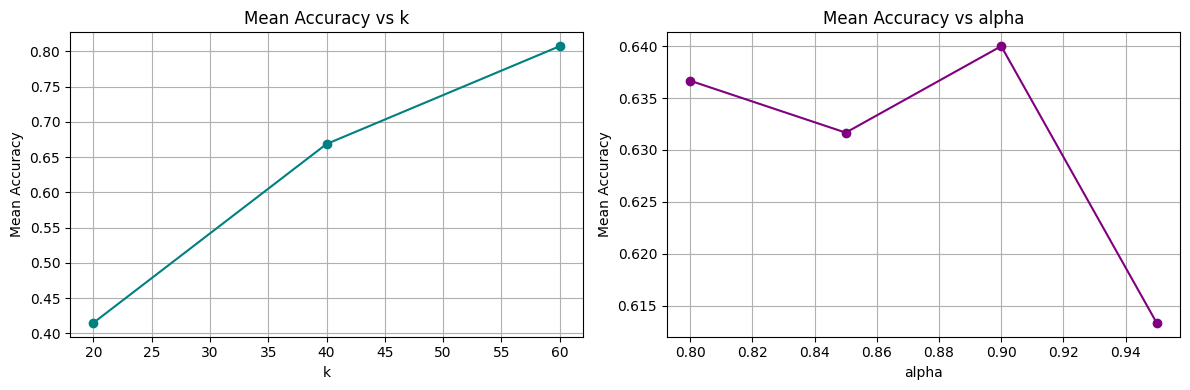

In [661]:
visual = visualize(k_means.accuracy)
visual.plot_separate()

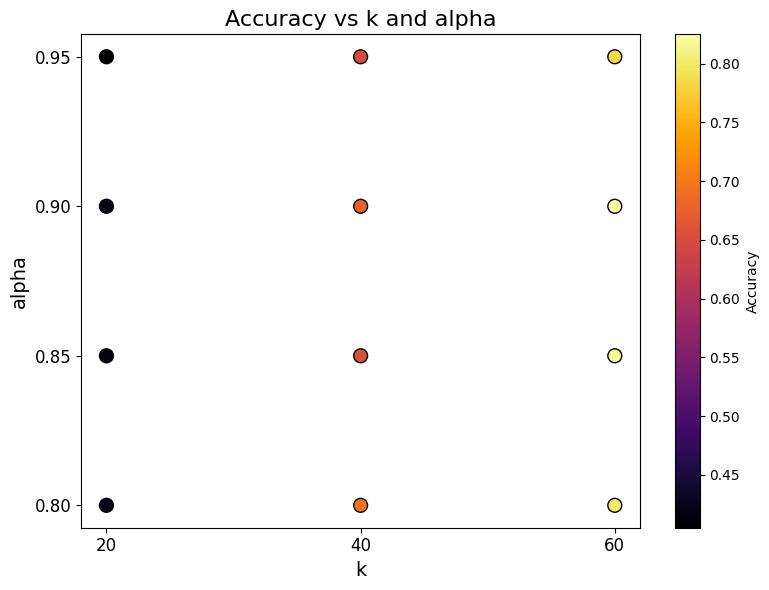

In [662]:
visual.plot_together()

In [663]:
visual.tabulate_separate()

| Type   |   Parameter |   Mean Accuracy |
|:-------|------------:|----------------:|
| k      |       20    |        0.415    |
| k      |       40    |        0.66875  |
| k      |       60    |        0.8075   |
| alpha  |        0.8  |        0.636667 |
| alpha  |        0.85 |        0.631667 |
| alpha  |        0.9  |        0.64     |
| alpha  |        0.95 |        0.613333 |


In [664]:
visual.tabulate_together()

╒═════╤═════════╤════════════╕
│   k │   alpha │   accuracy │
╞═════╪═════════╪════════════╡
│  20 │    0.8  │      0.415 │
├─────┼─────────┼────────────┤
│  20 │    0.85 │      0.42  │
├─────┼─────────┼────────────┤
│  20 │    0.9  │      0.42  │
├─────┼─────────┼────────────┤
│  20 │    0.95 │      0.405 │
├─────┼─────────┼────────────┤
│  40 │    0.8  │      0.695 │
├─────┼─────────┼────────────┤
│  40 │    0.85 │      0.655 │
├─────┼─────────┼────────────┤
│  40 │    0.9  │      0.675 │
├─────┼─────────┼────────────┤
│  40 │    0.95 │      0.65  │
├─────┼─────────┼────────────┤
│  60 │    0.8  │      0.8   │
├─────┼─────────┼────────────┤
│  60 │    0.85 │      0.82  │
├─────┼─────────┼────────────┤
│  60 │    0.9  │      0.825 │
├─────┼─────────┼────────────┤
│  60 │    0.95 │      0.785 │
╘═════╧═════════╧════════════╛


#### 4.1.3. Analysis

* There is a relation between the k and the accuracy   
---> A small k (e.g., 20) may not capture the underlying structure well (underfitting).   
---> A larger k (e.g., 60) allows more fine-grained clustering, which can better adapt to complex data distributions — especially after dimensionality reduction (PCA).   
---> At k = 20: Low accuracy (~0.41)   
---> At k = 40: Improved accuracy (~0.65–0.695)   
---> At k = 60: Best accuracy (~0.8–0.825)   
**so increasing k gives better clustering granularity, which results in better classification accuracy.**

* There is a relation between the alpha and accuracy:-   
---> At alpha = 0.8: Retains 80% of variance → more dimensionality reduction → less information, but simpler clusters.   
This will result in underfitting model which won't capture the complex details of data.   
---> alpha = 0.95: Retains 95% of variance → less reduction → more detailed data, but can introduce noise or redundancy.   
This will result in overfitting model which care about small changes and very sensitive to noise.   
**So the best accuracy will be at alpha 0.9 (better accuracy compared to alpha 0.85 as it capture more variation & details)**

### 4.2. Gaussian Mixture Model Clustering

#### 4.2.1. GMM Implementation

In [665]:
class GaussianMixtureModels:
    def __init__(self, n_components = 5, max_iter = 100, random_state = 42, init_params = ['random', 'kmeans']):
        self.n_components = n_components
        self.max_iter = max_iter
        self.random_state = random_state
        np.random.seed(random_state)
        self.init_params = init_params
        self.epsilon = 1e-6

    def _initialize_params(self, X_train):
        self.r = np.zeros((X_train.shape[0], self.n_components))

        self.mixture_weights = np.full((self.n_components,), 1 / self.n_components)

        if self.init_params == 'kmeans':
            kmeans = KMeans(n_clusters=self.n_components, random_state=self.random_state).fit(X_train)
            self.means = kmeans.cluster_centers_
        elif self.init_params == 'random':
            indices = np.random.choice(X_train.shape[0], self.n_components, replace=False)
            self.means = X_train[indices]

        self.cov_matrix = np.array([np.eye(X_train.shape[1]) for _ in range(self.n_components)])

    def fit(self, X_train):
        X_train = np.asarray(X_train)
        self._initialize_params(X_train)

        prev_means = self.means.copy()
        prev_covs = self.cov_matrix.copy()

        for i in range(self.max_iter):
            self._expectation(X_train)
            self._maximization(X_train)

            # Check if the means or covariances have changed significantly
            mean_diff = np.linalg.norm(self.means - prev_means)
            cov_diff = np.linalg.norm(self.cov_matrix - prev_covs)

            if mean_diff < 1e-6 and cov_diff < 1e-6:
                print(f"Converged at iteration {i} ...")
                break  # Stop if the change is small enough
            prev_means = self.means.copy()
            prev_covs = self.cov_matrix.copy()

    def predict(self, X_test):
        probs = self._compute_responsibilities_matrix(X_test)
        max_k = np.argmax(probs, axis=1)
        return max_k

    def _expectation(self, X_train):
        self.r = self._compute_responsibilities_matrix(X_train)

    def _maximization(self, X_train):
        self._compute_mixture_weights()
        self._compute_means(X_train)
        self._compute_cov_matrices(X_train)

    def _compute_responsibilities_matrix(self, X_train):
        log_prob = np.zeros((X_train.shape[0], self.n_components))
        for k in range(self.n_components):
            log_prob[:, k] = multivariate_normal(mean=self.means[k], cov=self.cov_matrix[k], allow_singular=True).logpdf(X_train)

        log_prob += np.log(self.mixture_weights)  # Avoid log(0)
        log_sum = logsumexp(log_prob, axis=1)[:, np.newaxis]
        log_r = log_prob - log_sum
        return np.exp(log_r)

    def _compute_mixture_weights(self):
        N = self.r.shape[0]
        self.mixture_weights = np.sum(self.r, axis=0) / N

    def _compute_means(self, X_train):
        for k in range(self.n_components):
            numerator = np.sum(self.r[:, k][:, np.newaxis] * X_train, axis=0)
            denominator = np.sum(self.r[:, k])
            self.means[k] = numerator / denominator

    def _compute_cov_matrices(self, X_train):
        for k in range(self.n_components):
            diff = X_train - self.means[k]
            weighted_outer = (self.r[:, k][:, np.newaxis] * diff).T @ diff
            denominator = np.sum(self.r[:, k])
            self.cov_matrix[k] = weighted_outer / denominator + np.eye(X_train.shape[1]) * self.epsilon

#### 4.2.2. Evaluation

In [666]:
class GMM_Evaluator:
    @staticmethod
    def mapping_GMM_labels(gmm, X_train, y_train, dim):
        y_pred = gmm.predict(X_train)
        labels = np.zeros((dim, dim ))
        for pred_label, true_label in zip(y_pred, y_train):
            labels[pred_label, true_label] += 1

        labels_dict = {}
        for i in range(dim):
            labels_dict[i] = np.argmax(labels[i], axis=0)
        return labels_dict

    def eval_GMM(self, alpha, gmm_accuracy, dim, k, X_train, X_test):
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        gmm = GaussianMixtureModels(n_components=k, random_state=42, max_iter=50, init_params='kmeans')
        gmm.fit(X_train_scaled)
        y_pred = gmm.predict(X_test_scaled)

        label_mapping = self.mapping_GMM_labels(gmm, X_train_scaled, y_train, dim)
        y_pred_mapped = [label_mapping[label]  for label in y_pred]
        accuracy = accuracy_score(y_test, y_pred_mapped)
        gmm_accuracy['k'].append(k)
        gmm_accuracy['alpha'].append(alpha)
        gmm_accuracy['accuracy'].append(accuracy)
        return y_pred_mapped

In [667]:
k_list = [20, 40, 60]
dim = 61
gmm_accuracy = {
            "k": [],
            "alpha": [],
            "accuracy": []
        }

for threshold in projected_data:
    for k in k_list:
        evaluator = GMM_Evaluator()
        evaluator.eval_GMM(threshold, gmm_accuracy, dim, k, projected_data[threshold]['train'],  projected_data[threshold]['train'])
        print(f"Accuracy for thershold = {threshold} and k = {k} : {gmm_accuracy['accuracy'][-1]}")
    print("________________________________________________________")

Converged at iteration 5 ...
Accuracy for thershold = 0.8 and k = 20 : 0.425
Converged at iteration 5 ...
Accuracy for thershold = 0.8 and k = 40 : 0.715
Converged at iteration 7 ...
Accuracy for thershold = 0.8 and k = 60 : 0.81
________________________________________________________
Converged at iteration 5 ...
Accuracy for thershold = 0.85 and k = 20 : 0.41
Converged at iteration 5 ...
Accuracy for thershold = 0.85 and k = 40 : 0.7
Converged at iteration 7 ...
Accuracy for thershold = 0.85 and k = 60 : 0.82
________________________________________________________
Converged at iteration 6 ...
Accuracy for thershold = 0.9 and k = 20 : 0.38
Converged at iteration 5 ...
Accuracy for thershold = 0.9 and k = 40 : 0.575
Converged at iteration 6 ...
Accuracy for thershold = 0.9 and k = 60 : 0.785
________________________________________________________
Converged at iteration 6 ...
Accuracy for thershold = 0.95 and k = 20 : 0.33
Converged at iteration 6 ...
Accuracy for thershold = 0.95 and

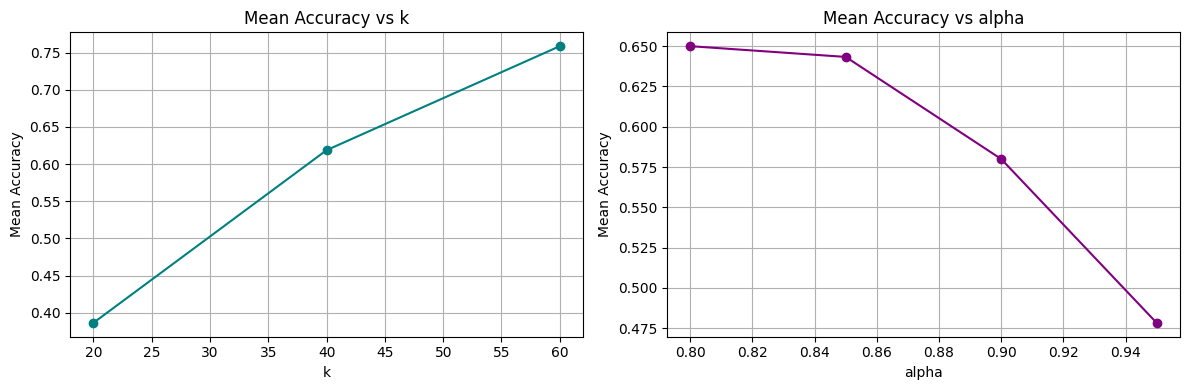

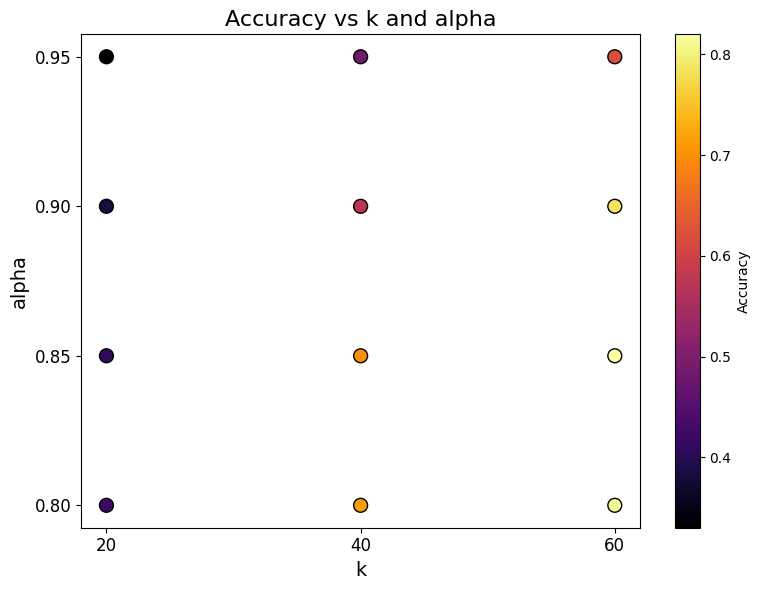

In [668]:
visual = visualize(gmm_accuracy)
visual.plot_separate()
visual.plot_together()

In [669]:
visual.tabulate_separate()

| Type   |   Parameter |   Mean Accuracy |
|:-------|------------:|----------------:|
| k      |       20    |        0.38625  |
| k      |       40    |        0.61875  |
| k      |       60    |        0.75875  |
| alpha  |        0.8  |        0.65     |
| alpha  |        0.85 |        0.643333 |
| alpha  |        0.9  |        0.58     |
| alpha  |        0.95 |        0.478333 |


In [670]:
visual.tabulate_together()

╒═════╤═════════╤════════════╕
│   k │   alpha │   accuracy │
╞═════╪═════════╪════════════╡
│  20 │    0.8  │      0.425 │
├─────┼─────────┼────────────┤
│  40 │    0.8  │      0.715 │
├─────┼─────────┼────────────┤
│  60 │    0.8  │      0.81  │
├─────┼─────────┼────────────┤
│  20 │    0.85 │      0.41  │
├─────┼─────────┼────────────┤
│  40 │    0.85 │      0.7   │
├─────┼─────────┼────────────┤
│  60 │    0.85 │      0.82  │
├─────┼─────────┼────────────┤
│  20 │    0.9  │      0.38  │
├─────┼─────────┼────────────┤
│  40 │    0.9  │      0.575 │
├─────┼─────────┼────────────┤
│  60 │    0.9  │      0.785 │
├─────┼─────────┼────────────┤
│  20 │    0.95 │      0.33  │
├─────┼─────────┼────────────┤
│  40 │    0.95 │      0.485 │
├─────┼─────────┼────────────┤
│  60 │    0.95 │      0.62  │
╘═════╧═════════╧════════════╛


#### 4.2.3. Analysis

Can you find a relation between **alpha** and **classification accuracy**?
- As alpha increases, accuracy decreases.

Can you find a relation between **K** and **classification accuracy**?
- As K increases, accuracy increases.

## 5. Evaluation

### 5.1. Best K-Means Model

* The best K_Means model: K = 60, Alpha = 0.9

In [671]:
best_k_means = K_Means()
best_model = best_k_means.model(60)
best_k_means.fit(best_model, projected_data[0.9]['test'], 0.9)
best_k_means.eval(best_model.labels, y_test.copy(), y_test)
print(best_model.labels)
print(best_k_means.accuracy)

[13 13 42 13 42 48 48 48 48 48  6  6 51 39  6 38 38  6 38 38 17 17  1 17
  1  9  9  9  9  9 41 41 41 41 41 50 23 23 50 23 31 31 31 39 31 21 37 56
 37 56 36 36 53 36 36 10  4  4  4 10 34 57 34 34 34 59 25 59 59 36 48 48
 16 16 16 48 13 42 30 30 15 55 15 35 35 58 58 58 58 58 28 28 28 28 48 32
 32 52 52  2 26 26 26 26 26 12 46 27 46 12 11 31 31 33 11  7  7 48  7  7
 29 29  8 29 29 14 14 14 14 14 19 19 19 55 55 18 18 49 49 15 24 24  0  0
 24 26 26 24 24 26 26  3  3 26 26 44 44 44 44 44 20 20 20 20 20 22 22 22
 22 22 17  5 40 45 40 54 54 54 35 54 18 18 49 18 18 39 47 47 47 39 43 43
 43 43 43  1  1  1  1 40]
{'k': [60], 'alpha': [0.9], 'accuracy': [np.float64(0.845)]}


In [672]:
acc = accuracy_score(y_test, best_k_means.y_predict)
print(f"Accuracy: {acc:.2f}")

Accuracy: 0.84


In [673]:

f1 = f1_score(y_test, best_k_means.y_predict, average='macro') 
print(f"F1 Score: {f1}")

F1 Score: 0.8343226911976911


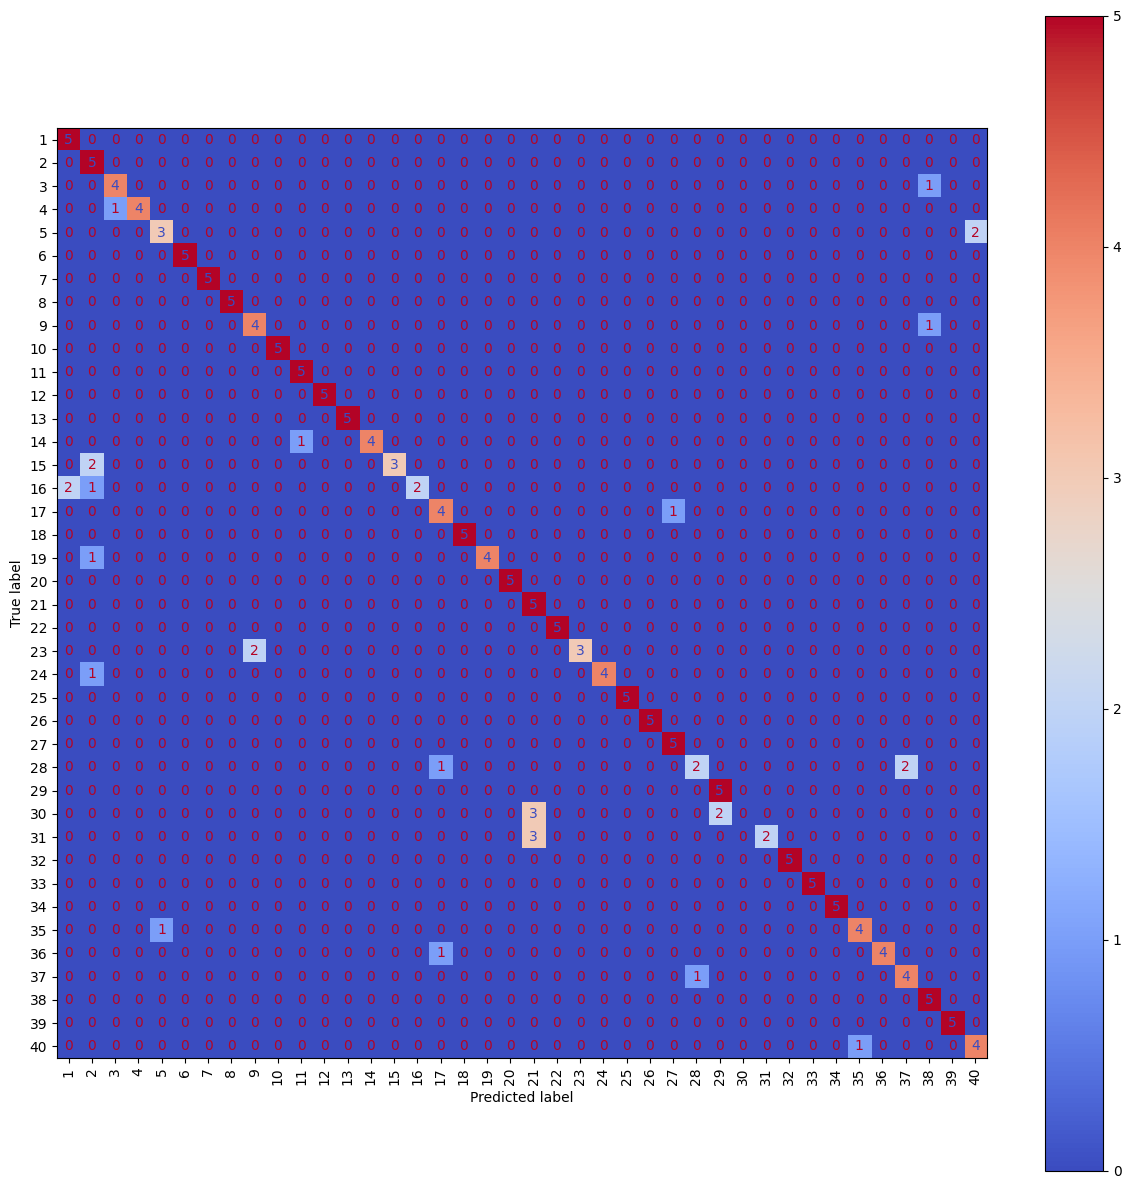

In [674]:
cm = confusion_matrix(y_test, best_k_means.y_predict, labels=range(1, 41))
fig, ax = plt.subplots(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(1, 41))
disp.plot(cmap='coolwarm', xticks_rotation = 90, ax=ax)
plt.show()

### 5.2. Best GMM Model

In [675]:
gmm_accuracy = {
            "k": [],
            "alpha": [],
            "accuracy": []
        }
evaluator = GMM_Evaluator()
y_pred_mapped = evaluator.eval_GMM(0.85, gmm_accuracy, 61, 60, projected_data[0.85]['train'], projected_data[0.85]['test'])
print(np.array(y_pred_mapped))
print(gmm_accuracy)

Converged at iteration 7 ...
[24 24  1  1 24  2  2  2  2  2  3  3  3  3  3  4  4  4  4  4  5  5  5  5
  5  6  6  6  6  6  7  7  7  7  7 15  8  8  8  8  9  9  9  9  9 10 10 10
 10 10 11 11 19 11 11 12 12 12 12 12 13  1 13 13  1 14 14 14 14 14 15 15
 15 15 15 16 27 16  1 27  1 36  1 17 17 18 18 18 18 18 19 19 19 19 22 20
 20  3  3 20 21 21 21 21 21 22 22 22 22 22 38 33 23 23 38 24 24 24 24 24
 25 25  5 25 25  4  4 26 28  4 27 27 27 27 27 28 28 28 37  1 29 29 29 29
 23 31 38 30 24 30 31 31 31 21 31 32 32 32 23 32 20 33 30 33 20 34 34 34
 34 34  9 35 35 35  1 36 36 36 22 36 28 28 37 28 28 38 38 38 38 38 15 28
 22 22 22 23 18 18  5 18]
{'k': [60], 'alpha': [0.85], 'accuracy': [0.74]}


In [676]:
acc = accuracy_score(y_test, y_pred_mapped)
print(f"Accuracy: {acc:.2f}")

Accuracy: 0.74


In [677]:
f1 = f1_score(y_test, y_pred_mapped, average='macro') 
print(f"F1 Score: {f1}")

F1 Score: 0.716519869019869


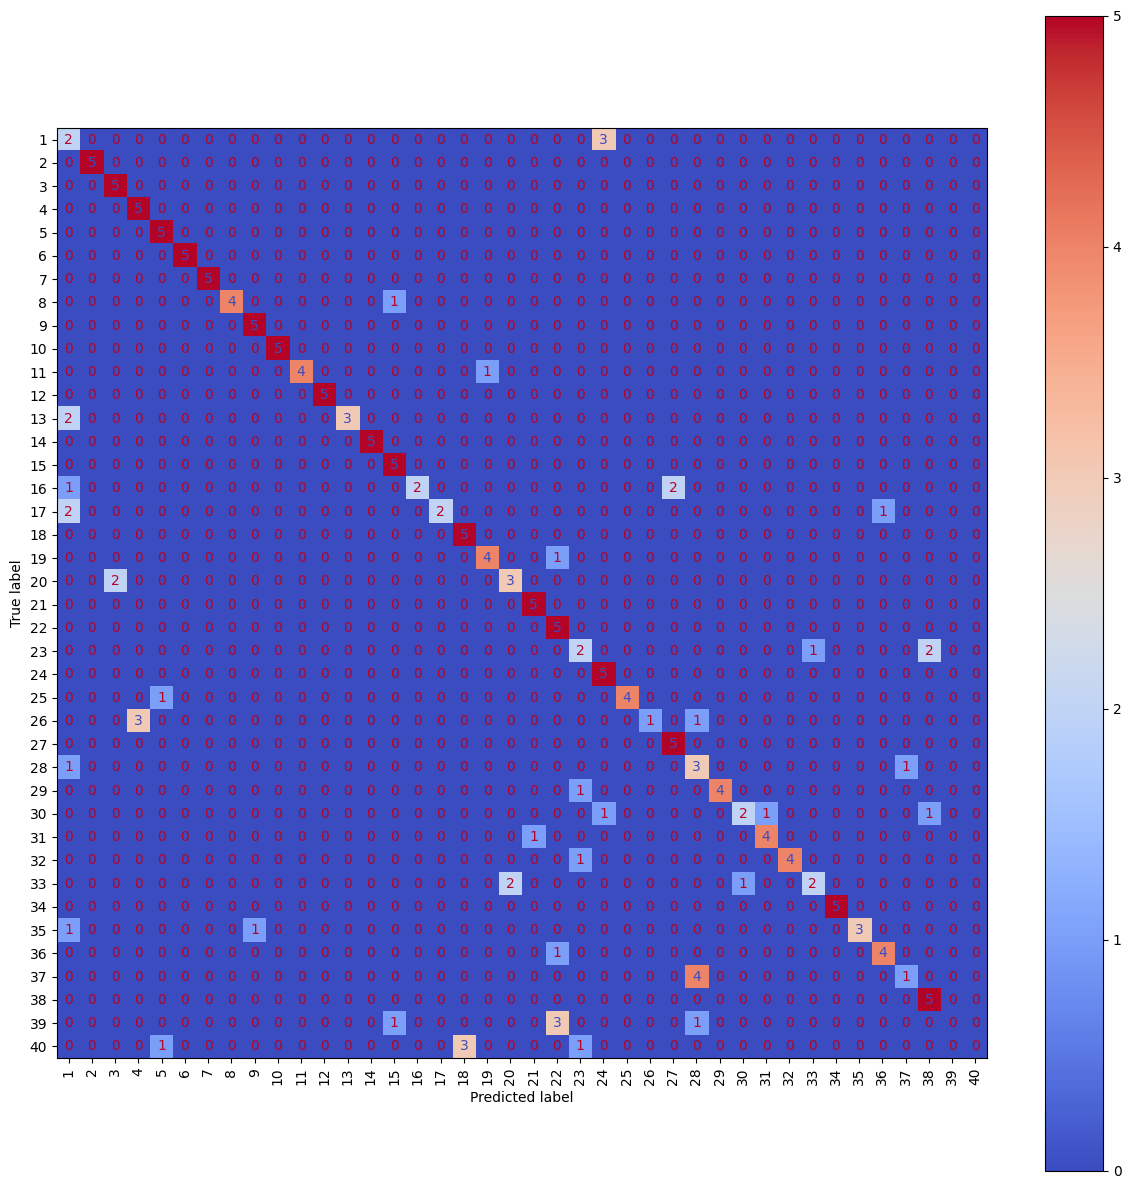

In [678]:
cm = confusion_matrix(y_test, y_pred_mapped, labels=range(1, 41))
fig, ax = plt.subplots(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(1, 41))
disp.plot(cmap='coolwarm', xticks_rotation = 90, ax=ax)
plt.show()

### 5.3. Comparison
## 📊 Clustering Model Comparison: K-Means vs GMM

This analysis compares the performance of two unsupervised learning models — **K-Means** and **Gaussian Mixture Model (GMM)** — on the same dataset after dimensionality reduction using PCA. The comparison focuses on the best-performing configurations for each model.

### 🔧 Experimental Setup

| Parameter | K-Means               | GMM                    |
|----------:|-----------------------|------------------------|
| **k**     | 60                    | 60                     |
| **PCA α** | 0.9 (90% variance retained) | 0.85 (85% variance retained) |

---

### ✅ Performance Metrics

| Metric        | K-Means   | GMM      |
|---------------|-----------|----------|
| **Accuracy**  | 0.84      | 0.74     |
| **F1 Score**  | 0.8343    | 0.7165   |   

> **Note:** Accuracy measures the overall correctness, while F1 Score balances precision and recall
---

### 🧠 Interpretation

- **K-Means** outperformed **GMM** across both accuracy and F1 Score.
- The **PCA threshold** played a role in feature compression:
  - K-Means performed best with **90% retained variance**, suggesting that it benefited from richer feature representation.
  - GMM peaked at **85% variance**, possibly due to overfitting at higher dimensions.

---

### 📌 Conclusion

K-Means provided better clustering quality in this experiment, both in terms of classification **accuracy** and **F1 score**. Its simpler assumptions (hard clustering and spherical clusters) likely aligned better with the structure of the PCA-reduced data.

## 6. Autoencoder for Dimensionality Reduction

### 6.1. Autoencoder Implementation

In [679]:
# normalizing the data 
X_train_normalized = face_dataset.X_train.astype(np.float32) / 255.0  # (200,10304)
X_test_normalized  = face_dataset.X_test.astype(np.float32)  / 255.0  # (200,10304)
# reshape to (N,1,112,92)
X_train_normalized = X_train_normalized.reshape(-1, 1, 112, 92)
X_test_normalized  = X_test_normalized.reshape(-1, 1, 112, 92)
y_train = face_dataset.y_train
y_test  = face_dataset.y_test

# data loader
batch_size = 32
tensor_train = torch.from_numpy(X_train_normalized)
train_ds = TensorDataset(tensor_train, tensor_train)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        # encoding (1,112,92) --> (256,7,6)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  nn.BatchNorm2d(32),  nn.LeakyReLU(0.2, True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, True),
            nn.Conv2d(64,128,3, stride=2, padding=1),   nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128,256,3,stride=2, padding=1),   nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True)
        )
        # bottleneck
        self.fc_enc = nn.Linear(256*7*6, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 256*7*6)
        # decoding (256,7,6) --> (1,112,92)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256,128,3,stride=2,padding=1,output_padding=(1,1)), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d(128,64, 3,stride=2,padding=1,output_padding=(1,0)),  nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d(64,32,  3,stride=2,padding=1,output_padding=(1,1)),   nn.BatchNorm2d(32),  nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d(32,1,   3,stride=2,padding=1,output_padding=(1,1)),   nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        z = self.fc_enc(h)
        h2 = self.fc_dec(z)
        h2 = h2.view(-1, 256, 7, 6)
        return self.decoder(h2), z

latent_dim = 128
model = Autoencoder(latent_dim=latent_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
model_path = 'autoencoder_trained_model.pth'

# load the model or train it 
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    model.eval()
    print(f"Loading model from {model_path}")
else:
    num_epochs = 100
    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss = 0.0
        for inputs, _ in train_loader:
            recon, _ = model(inputs)
            loss     = criterion(recon, inputs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        avg_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {avg_loss:.6f}')
    torch.save(model.state_dict(), model_path)


Loading model from autoencoder_trained_model.pth


In [680]:
# extracting latent features
model.eval()
with torch.no_grad():
    _, Z_train = model(torch.from_numpy(X_train_normalized))
    _, Z_test  = model(torch.from_numpy(X_test_normalized))
print(f"Encoded train shape: {Z_train.shape}")
print(f"Encoded test shape:  {Z_test.shape}")


Encoded train shape: torch.Size([200, 128])
Encoded test shape:  torch.Size([200, 128])


### 6.2. Clustering on Autoencoder Features

### 6.2.1 K means

##### K means training

In [681]:
k_means = K_Means()
for k in [20, 40, 60]:
    k_means_model = k_means.model(k)
    k_means.fit(k_means_model, Z_train.numpy(), alpha='AE')
    k_means.eval(k_means_model.labels, y_train.copy(), y_train)

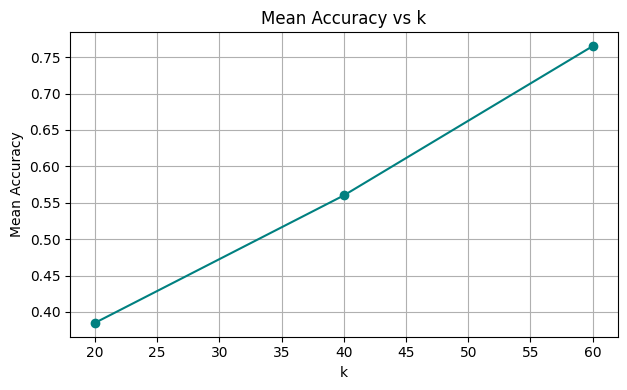

In [682]:
visual = visualize(k_means.accuracy)
visual.plot_separate()

#### K means evaluation

In [683]:
best_k_means = K_Means()
best_model = best_k_means.model(60)
best_k_means.fit(best_model, Z_test.numpy(), alpha='AE')
best_k_means.eval(best_model.labels, y_test.copy(), y_test)

In [684]:
acc = accuracy_score(y_test, best_k_means.y_predict)
print(f"Accuracy: {acc:.2f}")

Accuracy: 0.81


In [685]:

f1 = f1_score(y_test, best_k_means.y_predict, average='macro') 
print(f"F1 Score: {f1}")

F1 Score: 0.7814187201687202


### 6.2.2. GMM

#### GMM training

In [686]:
k_list = [20, 40, 60]
dim = 61
gmm_accuracy = {
            "k": [],
            "alpha": [],
            "accuracy": []
        }

for k in k_list:
    evaluator = GMM_Evaluator()
    evaluator.eval_GMM('AE', gmm_accuracy, dim, k, Z_train.numpy(),  Z_train.numpy())
    print(f"Accuracy for Autoencoder at k = {k} : {gmm_accuracy['accuracy'][-1]}")

Converged at iteration 4 ...
Accuracy for Autoencoder at k = 20 : 0.415
Converged at iteration 5 ...
Accuracy for Autoencoder at k = 40 : 0.67
Converged at iteration 6 ...
Accuracy for Autoencoder at k = 60 : 0.775


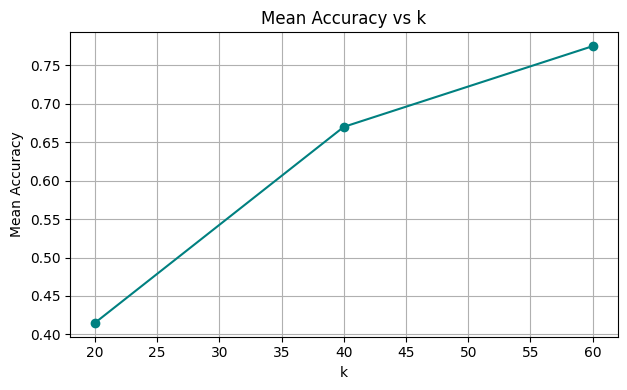

In [687]:
visual = visualize(gmm_accuracy)
visual.plot_separate()

#### GMM evaluation

In [688]:
gmm_accuracy = {
            "k": [],
            "alpha": [],
            "accuracy": []
        }
evaluator = GMM_Evaluator()
y_pred_mapped = evaluator.eval_GMM('AE', gmm_accuracy, 61, 60, Z_train.numpy(), Z_test.numpy())
print(np.array(y_pred_mapped))
print(gmm_accuracy)

Converged at iteration 6 ...
[24 24  1  1 16  2  2  2  2  2  3  3 13  3 18  4  4  4  4  4  5 38  5  5
  6  6  6  6  6  6  7  7  7  7  7  8  8  8  8  8 40 40 40  9  9 10 10 10
 10 23 11 11 19 11 11 12 12 12 12 12 13 13 13 13 13 19 14 19  4 14 15 11
 15 15 15 16 24 16 16 16  1 27  1  1  9 18 18 18 18 18 19 19 19 19 16 20
 20 20 20 20 21 21 21 21 21 22 22 22 22 22 23 40 23 23 23 24 24 24 24 24
 25 25  5 25 25  3  3 26 28  3 27 27 27 27 27 28 28 16 16 16 29 29 29 29
 29 30 30  9 30 30 30 31 31 21 30 32 32 32  2 32 21 33 21 33 21 34 34 34
 34 34 38 23 23 35  1 36 36 36 36 36 28 28 37 28 28 23 38 38 38 23 22 22
 22 15 22 40  4 18  5  5]
{'k': [60], 'alpha': ['AE'], 'accuracy': [0.705]}


In [689]:
acc = accuracy_score(y_test, y_pred_mapped)
print(f"Accuracy: {acc:.2f}")

Accuracy: 0.70


In [690]:
f1 = f1_score(y_test, y_pred_mapped, average='macro')
print(f"F1 Score: {f1}")

F1 Score: 0.6762726162726164


### 6.3. Comparison

| **Method**   | **Representation** | **Best k (α)**    | **Accuracy** | **F1 Score** |
|:------------:|:------------------:|:-----------------:|:------------:|:------------:|
| **K-Means**  | PCA                | 60 (α = 0.9)      | 0.84         | 0.83         |
|              | Autoencoder        | 60                | 0.81         | 0.78         |
| **GMM**      | PCA                | 60 (α = 0.85)     | 0.74         | 0.71        |
|              | Autoencoder        | 60                | 0.7          | 0.67         |

---

#### Insights

1. **K-Means + PCA vs. K-Means + Autoencoder**  
   - Both achieves pretty good accuracy 84% and 81% accuracy at k = 60.  
   - PCA’s F1 (0.83) slightly better than the autoencoder’s (0.78) 
   - PCA had the edge because:  
     - PCA finds global variance directions that align with class separations in a small dataset (400 faces).  
     - The autoencoder’s 128-dim nonlinear encoding can distribute class information unevenly causing a lower balance in each class.

2. **GMM + PCA vs. GMM + Autoencoder**  
   - PCA + GMM is 74% acc / 0.71 F1.  
   - Autoencoder + GMM drops to 70% acc / 0.67 F1 because:  
     - The autoencoder latent space may not form well separated Gaussian clusters.  

3. **Why PCA is more suitable here**  
   - **Deterministic vs. Iterative**  
     - PCA’s eigen decomposition is exact and requires no tuning.  
     - The autoencoder needed 100 epochs on only 200 training images making it prone to underfitting.  
   - **Hyperparameter Simplicity**  
     - PCA has a single hyperparameter (alpha). Easy to tune.  
     - Autoencoder has many (latent size, layers, batch size) making latent clustering more sensitive.  
   - **Efficiency**  
     - PCA runs in milliseconds after covariance calculation.  
     - Autoencoder takes so much time to complete 100 epoch.

---

**Conclusion:**  
On the small scale ORL face dataset PCA remains the prefered option for feature extraction for both K-Means and GMM clustering, as autoencoders need large volumes of data to learn nonlinear manifolds. So, data size limits generalization.



### 6.4. Visualization

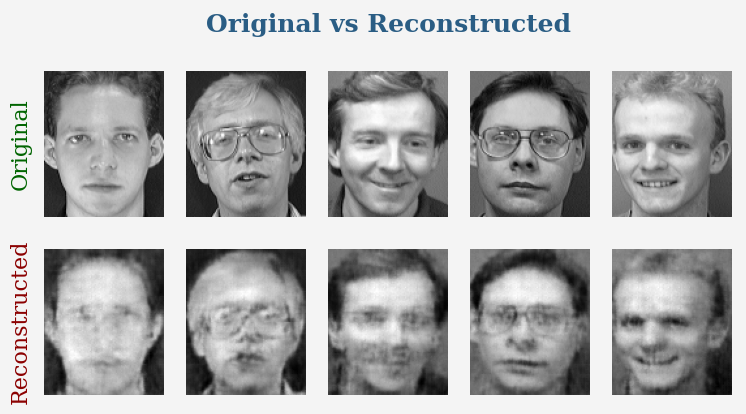

In [691]:
n_persons = 5                   
idxs = [i * 5 for i in range(n_persons)]  
orig = X_test_normalized[idxs].squeeze(1)
with torch.no_grad():
    recons, _ = model(torch.from_numpy(X_test_normalized[idxs]))
    recons = recons.numpy().squeeze(1)

fig = plt.figure(figsize=(9, 5), facecolor='#f4f4f4')
gs = gridspec.GridSpec(3, n_persons, height_ratios=[0.2, 1, 1], hspace=0.3, wspace=0.1)


axis_title = fig.add_subplot(gs[0, :])
axis_title.axis('off')
axis_title.text(0.5, 0.5, f"Original vs Reconstructed", ha='center', va='center', fontdict=font1)


row_labels = ['Original', 'Reconstructed']
for i in range(2):
    for j in range(n_persons):
        ax = fig.add_subplot(gs[i+1, j])
        img = orig[j] if i == 0 else recons[j]
        ax.imshow(img.reshape(112, 92), cmap='gray')
        ax.axis('off')
        if j == 0:
            cf = font2 if i == 0 else font3
            ax.text(-0.1, 0.5, row_labels[i], transform=ax.transAxes, rotation=90, fontdict=cf, va='center', ha='right')
plt.show()